# DATASET ADULTS

In [30]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
matplotlib.__version__

'3.10.0'

## CARGA DEL DATASET (ya "limpio" en adult_final.csv)

In [31]:
RUTA = 'https://raw.githubusercontent.com/SonikoKatsura/CURSO_PARO_IA/refs/heads/main/Rober_IA/Modulo2/datos/adult_final.csv'

df_adult = pd.read_csv(RUTA)

df_adult.sample(n=10)


,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,income,capital_dif
19747,28,Private,HS-grad,Never-married,Craft-repair,Unmarried,White,Male,40,United-States,0,2354
603,29,Private,HS-grad,Never-married,Craft-repair,Not-in-family,Amer-Indian-Eskimo,Male,40,United-States,0,0
915,25,Private,Some-college,Never-married,Transport-moving,Unmarried,White,Male,40,United-States,0,0
17660,18,NaN,Some-college,Never-married,NaN,Own-child,White,Female,24,United-States,0,-1602
17978,31,Self-emp-inc,Bachelors,Never-married,Prof-specialty,Not-in-family,White,Male,45,United-States,1,0
28615,22,Federal-gov,Some-college,Never-married,Adm-clerical,Own-child,Black,Male,20,United-States,0,0
8580,49,Private,Assoc-voc,Divorced,Sales,Unmarried,White,Female,40,United-States,0,0
5305,33,Private,HS-grad,Divorced,Adm-clerical,Own-child,White,Male,40,United-States,0,0
5724,43,Self-emp-inc,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,40,United-States,0,0
8018,59,Private,HS-grad,Divorced,Other-service,Unmarried,White,Female,40,United-States,0,0


In [32]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29096 entries, 0 to 29095
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             29096 non-null  int64 
 1   workclass       27464 non-null  object
 2   education       29096 non-null  object
 3   marital_status  29096 non-null  object
 4   occupation      27457 non-null  object
 5   relationship    29096 non-null  object
 6   race            29096 non-null  object
 7   sex             29096 non-null  object
 8   hours_per_week  29096 non-null  int64 
 9   native_country  28516 non-null  object
 10  income          29096 non-null  int64 
 11  capital_dif     29096 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 2.7+ MB


In [33]:
# variables numericas
df_adult.describe()


,age,hours_per_week,income,capital_dif
count,29096.000000,29096.000000,29096.000000,29096.000000
mean,39.251340,40.637820,0.247800,1100.627028
std,13.687157,12.735418,0.431743,7804.701906
min,17.000000,1.000000,0.000000,-4356.000000
25%,28.000000,40.000000,0.000000,0.000000
50%,38.000000,40.000000,0.000000,0.000000
75%,48.000000,45.000000,0.000000,0.000000
max,90.000000,99.000000,1.000000,99999.000000


In [34]:
# variables categoricas
df_adult.describe(include=['object'])

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
count,27464,29096,29096,27457,29096,29096,29096,28516
unique,8,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,19621,8886,13249,3885,11506,24438,19246,25721


### Algunos cambios previos

**NOTA: cambiar el orden de las columnas para ordenarlas (mínimo que la última columna sea target)**

In [35]:
df_adult.columns

Index(['age', 'workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'hours_per_week', 'native_country',
       'income', 'capital_dif'],
      dtype='object')

**Aprovechamos y nos quitamos de encima las columnas 'fnlwgt' y 'education_num':**

In [36]:
df_adult = df_adult[['age', 'sex', 'marital_status', 'relationship', 'race', 'native_country', 'education', 'workclass', 'occupation',
                    'hours_per_week',  'capital_dif', 'income']]

In [37]:
df_adult.head()

,age,sex,marital_status,relationship,race,native_country,education,workclass,occupation,hours_per_week,capital_dif,income
0,39,Male,Never-married,Not-in-family,White,United-States,Bachelors,State-gov,Adm-clerical,40,2174,0
1,50,Male,Married-civ-spouse,Husband,White,United-States,Bachelors,Self-emp-not-inc,Exec-managerial,13,0,0
2,38,Male,Divorced,Not-in-family,White,United-States,HS-grad,Private,Handlers-cleaners,40,0,0
3,53,Male,Married-civ-spouse,Husband,Black,United-States,11th,Private,Handlers-cleaners,40,0,0
4,28,Female,Married-civ-spouse,Wife,Black,Cuba,Bachelors,Private,Prof-specialty,40,0,0


# ANÁLISIS UNIDIMENSIONAL

Separamos variables por tipo:

In [38]:
variables_numericas = df_adult.select_dtypes(exclude=['object']).columns.to_list()

variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

In [39]:
variables_categoricas = df_adult.select_dtypes(include=['object']).columns.to_list()

variables_categoricas

['sex',
 'marital_status',
 'relationship',
 'race',
 'native_country',
 'education',
 'workclass',
 'occupation']

In [40]:
target = 'income'

## NUMERICAS: histograma y función de densidad

### Primer acercamiento

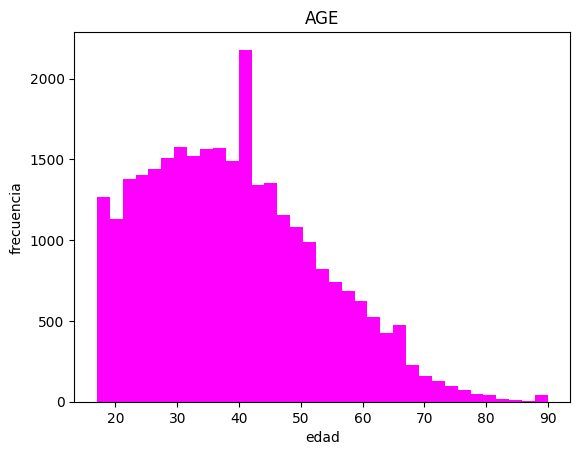

In [41]:
plt.hist(df_adult.age, bins=35, color='magenta')
plt.title('AGE')
plt.xlabel('edad')
plt.ylabel('frecuencia');

### Una sola gráfica con SUBPLOTS

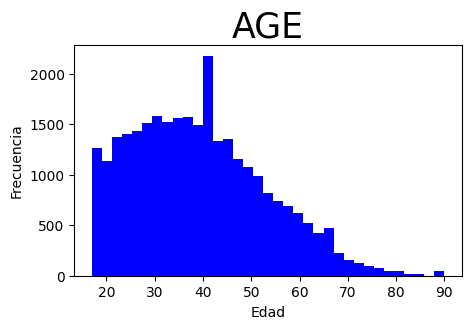

In [42]:
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_adult.age, bins=35, color='blue')

ax.set_title('AGE', fontsize=25)
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia');



In [43]:
variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

### EJERCICIO 1.

Haz el resto de gráficas, excepto la de 'income'

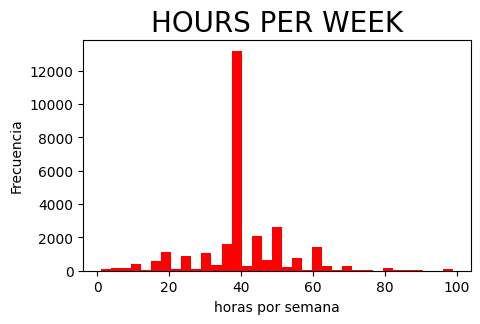

In [53]:
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_adult.hours_per_week, bins=35, color='red')

ax.set_title('HOURS PER WEEK', fontsize=20)
ax.set_xlabel('horas por semana')
ax.set_ylabel('Frecuencia');


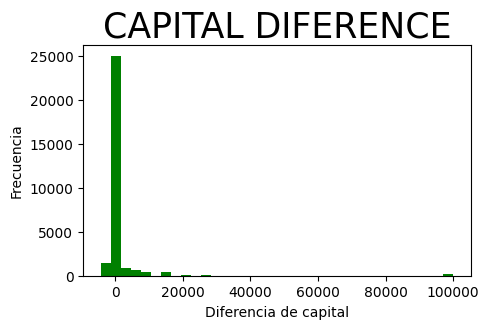

In [46]:
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_adult.capital_dif, bins=35, color='green')

ax.set_title('CAPITAL DIFERENCE', fontsize=25)
ax.set_xlabel('Diferencia de capital')
ax.set_ylabel('Frecuencia');


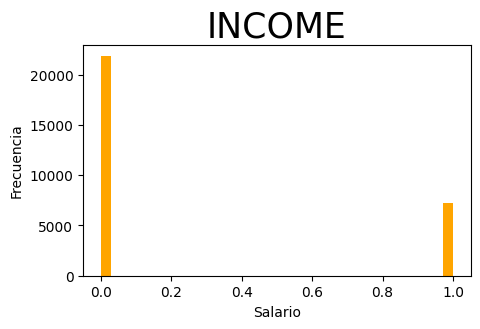

In [47]:
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_adult.income, bins=35, color='orange')

ax.set_title('INCOME', fontsize=25)
ax.set_xlabel('Salario')
ax.set_ylabel('Frecuencia');

### - Agrupar gráficas (subplots)

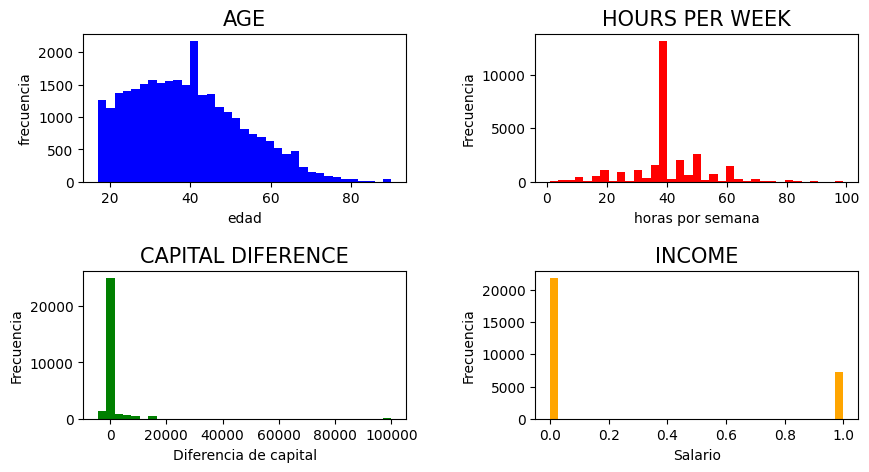

In [64]:
fig, ax = plt.subplots(2,2,figsize=(10,5), gridspec_kw={'hspace': 0.6, 'wspace': 0.4})

ax[0,0].hist(df_adult.age, bins=35, color='blue')

ax[0,0].set_title('AGE', fontsize=15)
ax[0,0].set_xlabel('edad')
ax[0,0].set_ylabel('frecuencia');

ax[0,1].hist(df_adult.hours_per_week, bins=35, color='red')

ax[0,1].set_title('HOURS PER WEEK', fontsize=15)
ax[0,1].set_xlabel('horas por semana')
ax[0,1].set_ylabel('Frecuencia');

ax[1,0].hist(df_adult.capital_dif, bins=35, color='green')

ax[1,0].set_title('CAPITAL DIFERENCE', fontsize=15)
ax[1,0].set_xlabel('Diferencia de capital')
ax[1,0].set_ylabel('Frecuencia');

ax[1,1].hist(df_adult.income, bins=35, color='orange')

ax[1,1].set_title('INCOME', fontsize=15)
ax[1,1].set_xlabel('Salario')
ax[1,1].set_ylabel('Frecuencia');

**Pregunta: ¿qué sentido tiene la indexación de ejes? (los números entre corchetes)**

*   ***Se refiere a la posicion en la tabla según los subplots que hemos creado.***




In [ ]:
variables_numericas

### EJERCICIO 2.

Haz el resto de gráficas, excepto la de 'income', pero presentalas primero horizontalmente (izda-drcha) y luego verticalmente (arriba-abajo). Sugerencia: de las etiquetas solo es necesaria el título

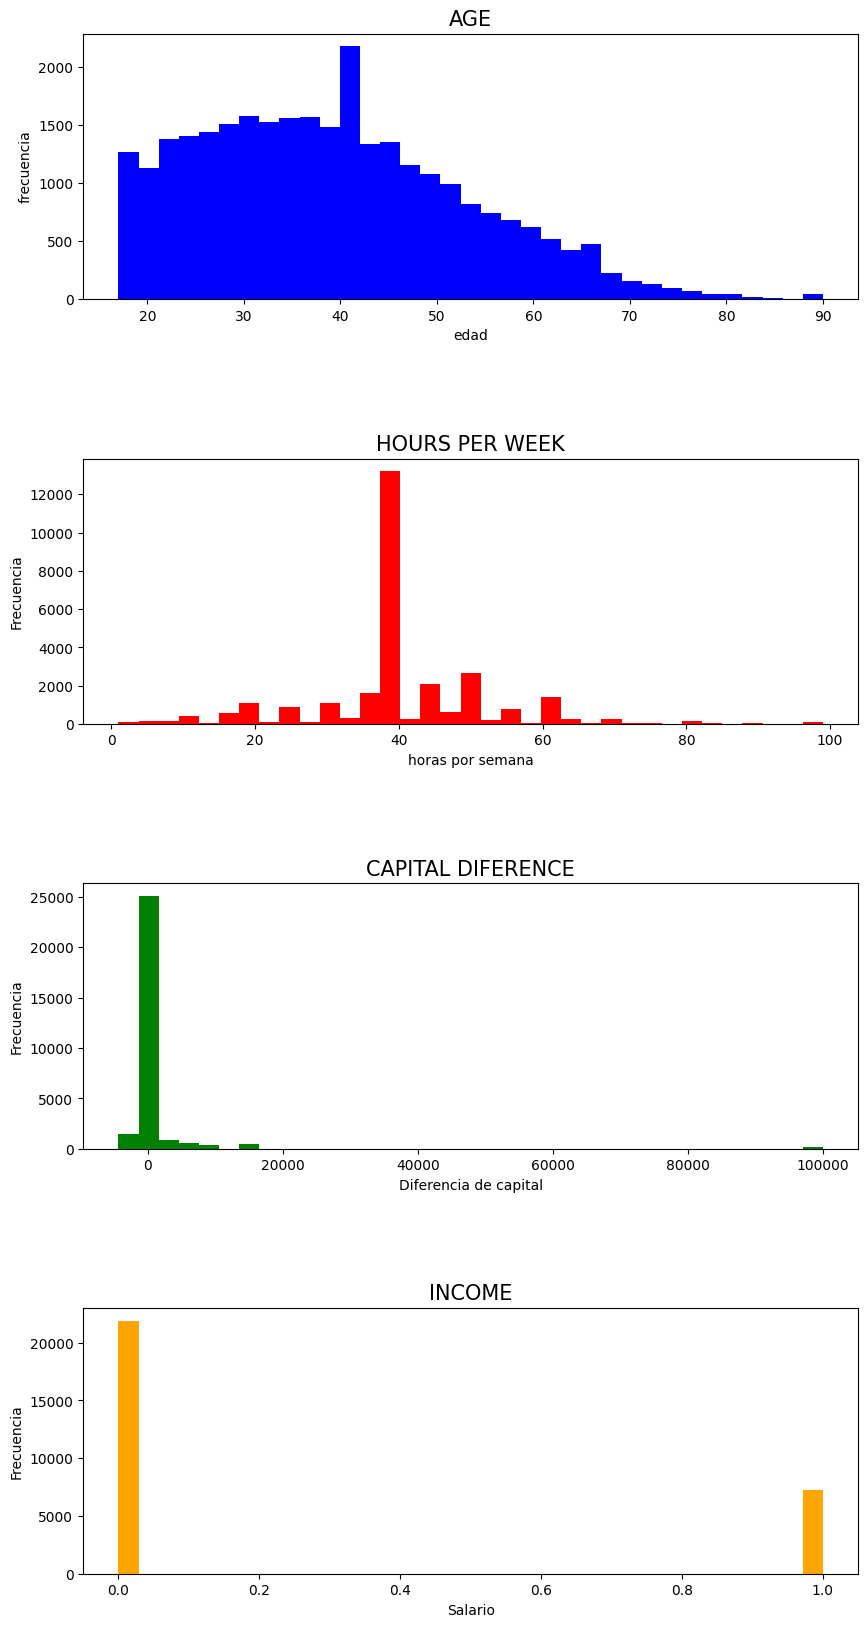

In [70]:
fig, ax = plt.subplots(4,1,figsize=(10,20), gridspec_kw={'hspace': 0.6, 'wspace': 0.4})

ax[0].hist(df_adult.age, bins=35, color='blue')

ax[0].set_title('AGE', fontsize=15)
ax[0].set_xlabel('edad')
ax[0].set_ylabel('frecuencia');

ax[1].hist(df_adult.hours_per_week, bins=35, color='red')

ax[1].set_title('HOURS PER WEEK', fontsize=15)
ax[1].set_xlabel('horas por semana')
ax[1].set_ylabel('Frecuencia');

ax[2].hist(df_adult.capital_dif, bins=35, color='green')

ax[2].set_title('CAPITAL DIFERENCE', fontsize=15)
ax[2].set_xlabel('Diferencia de capital')
ax[2].set_ylabel('Frecuencia');

ax[3].hist(df_adult.income, bins=35, color='orange')

ax[3].set_title('INCOME', fontsize=15)
ax[3].set_xlabel('Salario')
ax[3].set_ylabel('Frecuencia');

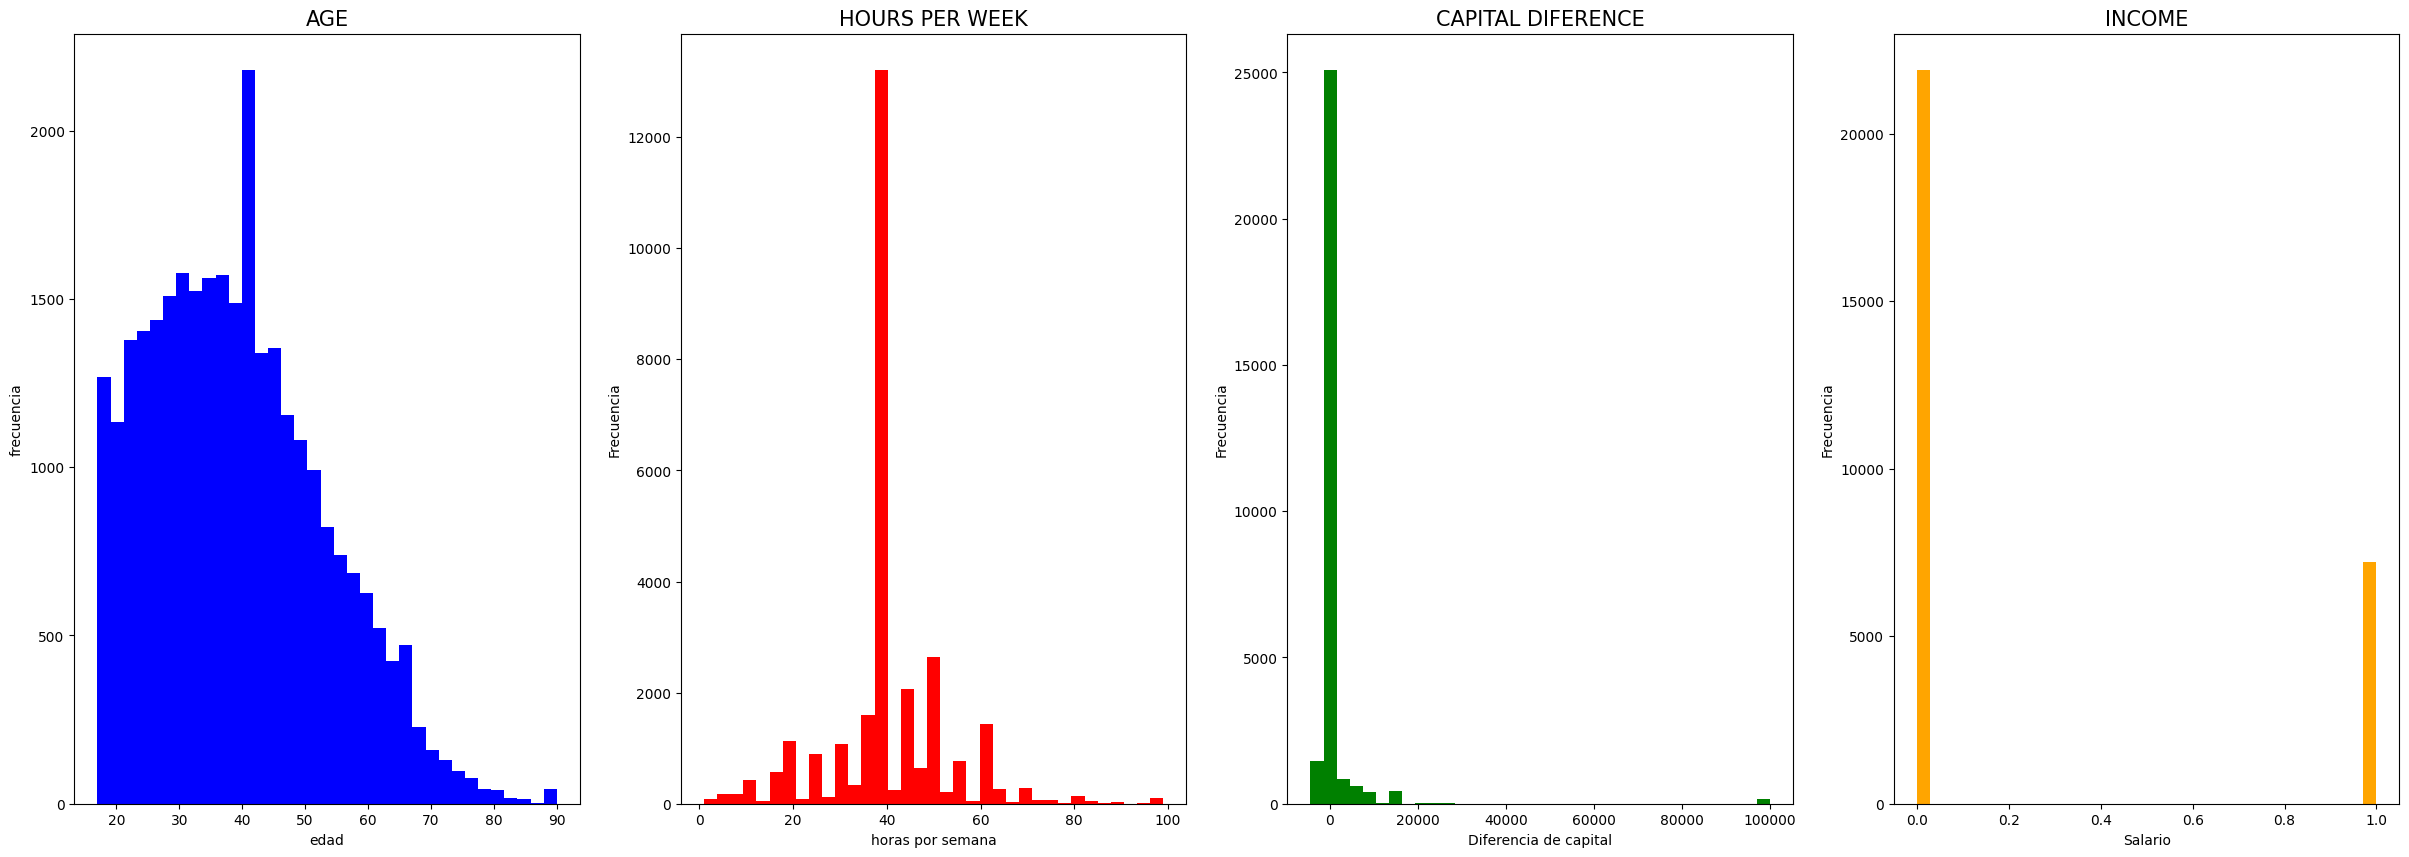

In [77]:
fig, ax = plt.subplots(1,4,figsize=(30,10), gridspec_kw={'hspace': 0.4, 'wspace': 0.2})

ax[0].hist(df_adult.age, bins=35, color='blue')

ax[0].set_title('AGE', fontsize=15)
ax[0].set_xlabel('edad')
ax[0].set_ylabel('frecuencia');

ax[1].hist(df_adult.hours_per_week, bins=35, color='red')

ax[1].set_title('HOURS PER WEEK', fontsize=15)
ax[1].set_xlabel('horas por semana')
ax[1].set_ylabel('Frecuencia');

ax[2].hist(df_adult.capital_dif, bins=35, color='green')

ax[2].set_title('CAPITAL DIFERENCE', fontsize=15)
ax[2].set_xlabel('Diferencia de capital')
ax[2].set_ylabel('Frecuencia');

ax[3].hist(df_adult.income, bins=35, color='orange')

ax[3].set_title('INCOME', fontsize=15)
ax[3].set_xlabel('Salario')
ax[3].set_ylabel('Frecuencia');

### - Uso de  libreria "Seaborn" + Agrupar gráficas (subplots)

Primero uno solo:

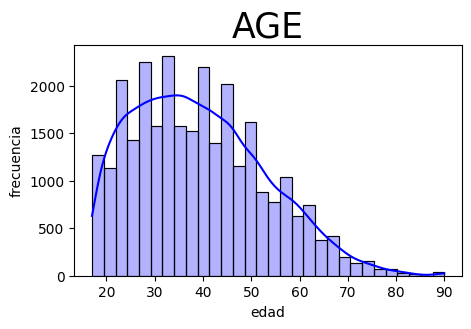

In [98]:
fig, mi_ax = plt.subplots(figsize=(5,3))

sns.histplot(df_adult.age, bins=30, ax=mi_ax, color='blue', kde=True, alpha=.3)

mi_ax.set_title('AGE', fontsize=25)
mi_ax.set_xlabel('edad')
mi_ax.set_ylabel('frecuencia');

Con varias graficas solo hay que pasar el eje al método de seaborn:


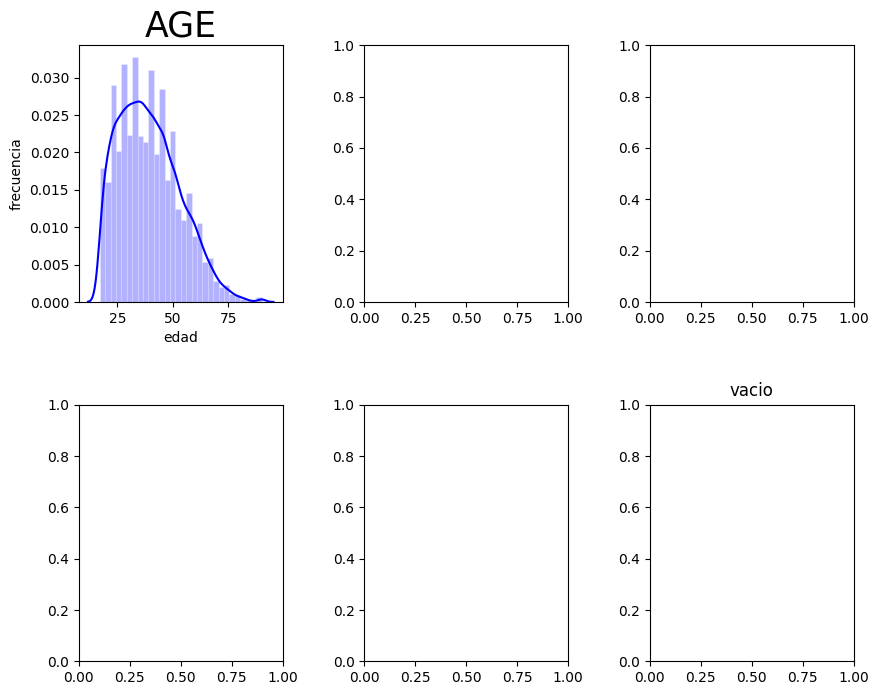

In [94]:
fig, ax = plt.subplots(2,3,figsize=(10,8), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.histplot(df_adult.age, bins=30, ax=ax[0,0], color='blue', kde=True, alpha=.3)
ax[0,0].set_title('AGE', fontsize=25)
ax[0,0].set_xlabel('edad')
ax[0,0].set_ylabel('frecuencia')

ax[1,2].set_title('vacio');

### EJERCICIO 3.

Haz de nuevo el EJERCICIO 2, pero esta vez utilizando la librería SEABORN

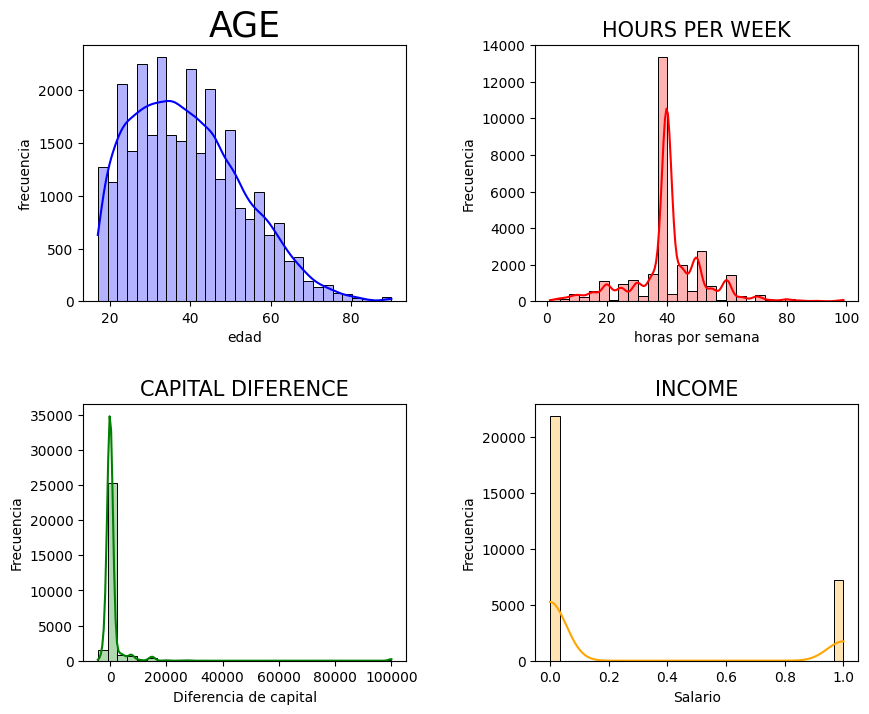

In [101]:
fig, ax = plt.subplots(2,2,figsize=(10,8), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.histplot(df_adult.age, bins=30, ax=ax[0,0], color='blue', kde=True, alpha=.3)

ax[0,0].set_title('AGE', fontsize=25)
ax[0,0].set_xlabel('edad')
ax[0,0].set_ylabel('frecuencia')

sns.histplot(df_adult.hours_per_week, bins=30, ax=ax[0,1],color='red', kde=True, alpha=.3)

ax[0,1].set_title('HOURS PER WEEK', fontsize=15)
ax[0,1].set_xlabel('horas por semana')
ax[0,1].set_ylabel('Frecuencia');

sns.histplot(df_adult.capital_dif, bins=30, ax=ax[1,0],color='green', kde=True, alpha=.3)

ax[1,0].set_title('CAPITAL DIFERENCE', fontsize=15)
ax[1,0].set_xlabel('Diferencia de capital')
ax[1,0].set_ylabel('Frecuencia');

sns.histplot(df_adult.income, bins=30, ax=ax[1,1], color='orange', kde=True, alpha=.3)

ax[1,1].set_title('INCOME', fontsize=15)
ax[1,1].set_xlabel('Salario')
ax[1,1].set_ylabel('Frecuencia');

In [96]:
variables_numericas

['age', 'hours_per_week', 'capital_dif', 'income']

### - Ultima vuelta de tuerca: varias representaciones en la misma gráfica:

<ipython-input-103-2a65883625a7>:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  mi_ax.legend();


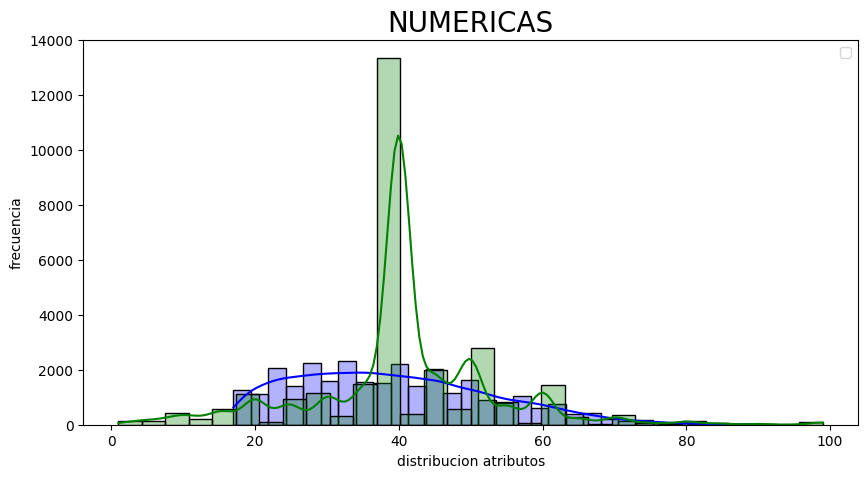

In [103]:
fig, mi_ax = plt.subplots(figsize=(10,5))

sns.histplot(df_adult.age, bins=30, ax=mi_ax, color='blue', kde=True, alpha=.3)
sns.histplot(df_adult.hours_per_week, bins=30, ax=mi_ax, color='green', kde=True, alpha=.3)

mi_ax.set_title('NUMERICAS', fontsize=20)
mi_ax.set_xlabel('distribucion atributos')
mi_ax.set_ylabel('frecuencia')
mi_ax.legend();


## NUMERICAS: diagrama de cajas

### - Uso de "boxplot"

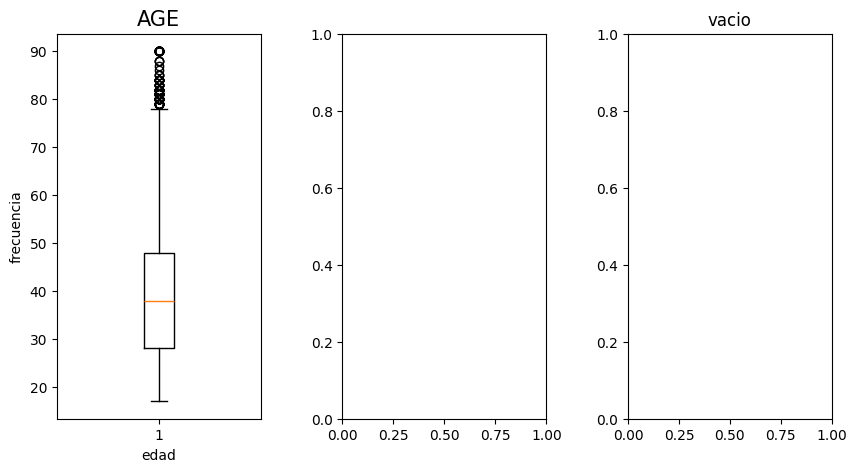

In [105]:
fig, mi_ax = plt.subplots(1,3,figsize=(10,5), gridspec_kw={'hspace': 0.4, 'wspace': 0.4},)

mi_ax[0].boxplot(df_adult.age)

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_xlabel('edad')
mi_ax[0].set_ylabel('frecuencia')

mi_ax[2].set_title('vacio');

### EJERCICIO 4.

Haz el resto de gráficas, excepto la de 'income', horizontalmente (izda-drcha) y verticalmente. Para esta última busca en la doc "matplotlib boxplot" cómo actúa el parámetro "vert". Sugerencia: de las etiquetas solo es necesaria el título

Text(0.5, 0, 'Salario')

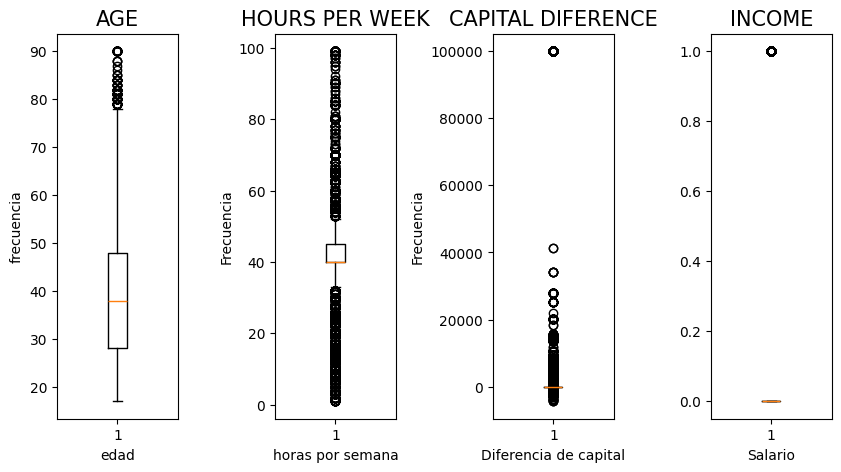

In [111]:
fig, mi_ax = plt.subplots(1,4,figsize=(10,5), gridspec_kw={'hspace': 0.4, 'wspace': 0.8},)

mi_ax[0].boxplot(df_adult.age, orientation='vertical')

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_xlabel('edad')
mi_ax[0].set_ylabel('frecuencia')

mi_ax[1].boxplot(df_adult.hours_per_week, orientation='vertical')

mi_ax[1].set_title('HOURS PER WEEK', fontsize=15)
mi_ax[1].set_xlabel('horas por semana')
mi_ax[1].set_ylabel('Frecuencia');

mi_ax[2].boxplot(df_adult.capital_dif, orientation='vertical')

mi_ax[2].set_title('CAPITAL DIFERENCE', fontsize=15)
mi_ax[2].set_xlabel('Diferencia de capital')
mi_ax[2].set_ylabel('Frecuencia');

mi_ax[3].boxplot(df_adult.income, orientation='vertical')

mi_ax[3].set_title('INCOME', fontsize=15)
mi_ax[3].set_xlabel('Salario')

Text(0.5, 0, 'Salario')

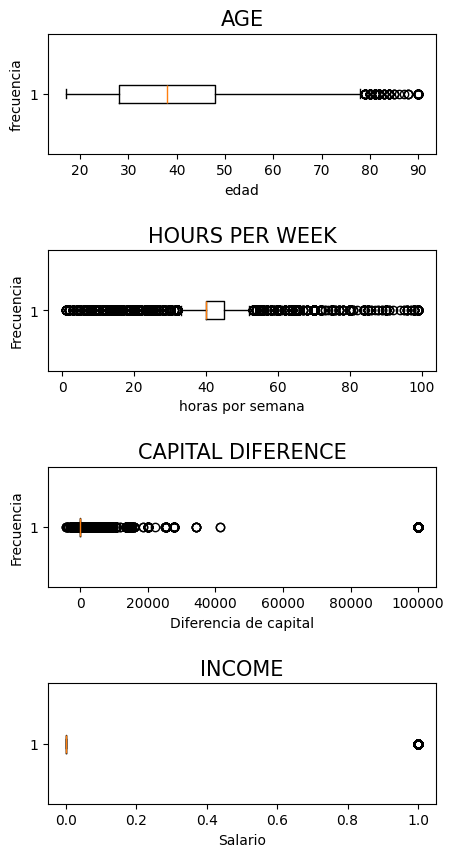

In [114]:
fig, mi_ax = plt.subplots(4,1,figsize=(5,10), gridspec_kw={'hspace': 0.8, 'wspace': 0.4},)

mi_ax[0].boxplot(df_adult.age, orientation='horizontal')

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_xlabel('edad')
mi_ax[0].set_ylabel('frecuencia')

mi_ax[1].boxplot(df_adult.hours_per_week, orientation='horizontal')

mi_ax[1].set_title('HOURS PER WEEK', fontsize=15)
mi_ax[1].set_xlabel('horas por semana')
mi_ax[1].set_ylabel('Frecuencia');

mi_ax[2].boxplot(df_adult.capital_dif, orientation='horizontal')

mi_ax[2].set_title('CAPITAL DIFERENCE', fontsize=15)
mi_ax[2].set_xlabel('Diferencia de capital')
mi_ax[2].set_ylabel('Frecuencia');

mi_ax[3].boxplot(df_adult.income, orientation='horizontal')

mi_ax[3].set_title('INCOME', fontsize=15)
mi_ax[3].set_xlabel('Salario')

### - Uso de  libreria "Seaborn"

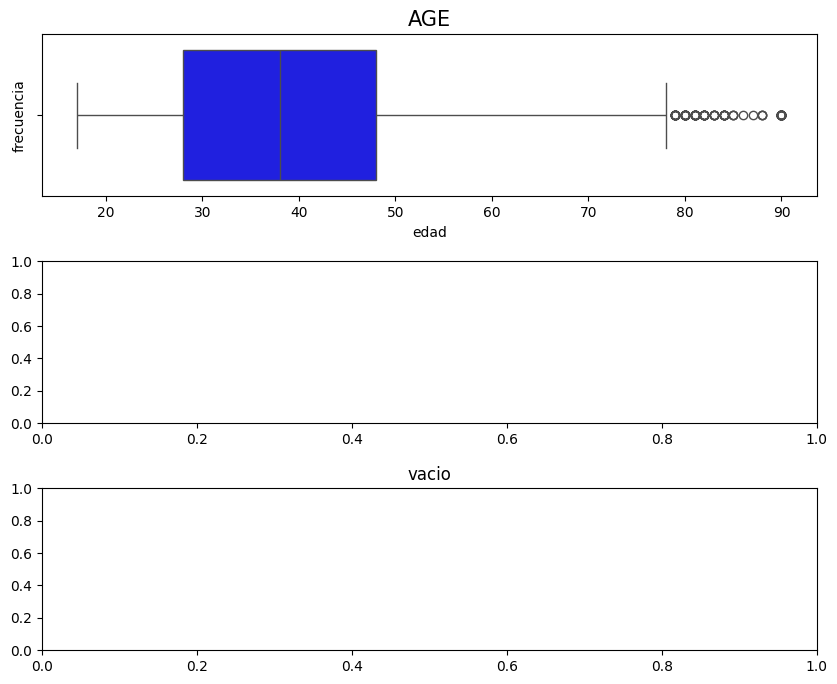

In [97]:
fig, mi_ax = plt.subplots(3,1,figsize=(10,8), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.boxplot(x='age', data=df_adult, ax=mi_ax[0], color='blue')

mi_ax[0].set_title('AGE', fontsize=15)
mi_ax[0].set_xlabel('edad')
mi_ax[0].set_ylabel('frecuencia')

mi_ax[2].set_title('vacio');

### EJERCICIO 5.

Haz de nuevo el EJERCICIO 4, pero esta vez utilizando la librería SEABORN

### - Ultima vuelta de tuerca: BIDIMENSIONAL, estudio var. numérica según valores var. categórica, varias representaciones en la misma gráfica.

In [ ]:
variables_numericas

In [ ]:
variables_categoricas

**- Grupos por género**

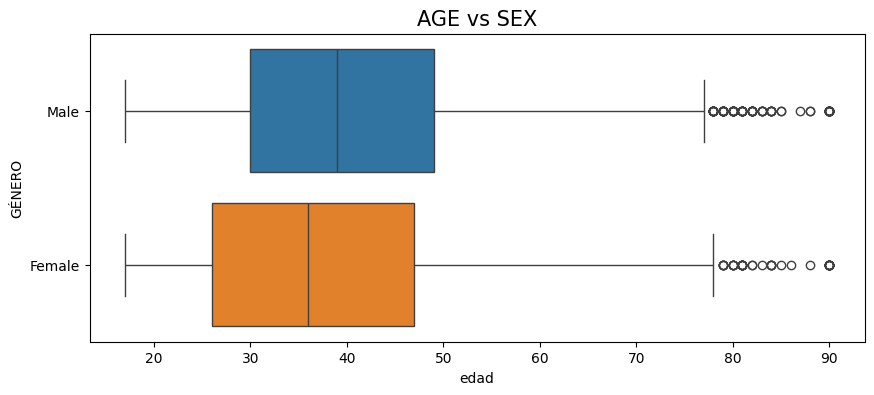

In [118]:
fig, mi_ax = plt.subplots(figsize=(10,4), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.boxplot(x='age', y='sex', hue='sex', data=df_adult, ax=mi_ax)

mi_ax.set_title('AGE vs SEX', fontsize=15)
mi_ax.set_xlabel('edad')
mi_ax.set_ylabel('GÉNERO');

### EJERCICIO 6.

Haz una gráfica similar a la anterior, esta vez con "hours_per_week" vs "sex".
¿Puedes sacar alguna conclusión o hipótesis?

## CATEGÓRICAS: diagrama de barras

In [ ]:
for categorica in variables_categoricas:

    print(f'Variable {categorica.upper()}:')
    print('Valores unicos: ')
    print(df_adult[categorica].unique(), end='\n'*2)
    print(df_adult[categorica].value_counts(), end='\n'*2)

In [ ]:
variables_categoricas

**Nos centraremos en las  columnas ['sex', 'marital_status', 'relationship', 'race']**

### - Uso de "boxplot"

Echemos un vistazo a "value_counts()":

In [ ]:
df_adult.marital_status.value_counts()


In [ ]:
fig, mi_ax = plt.subplots(figsize=(15,3), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

valores_unicos = df_adult.marital_status.value_counts().index
conteo = df_adult.marital_status.value_counts().values

mi_ax.bar(x=valores_unicos, height=conteo)

mi_ax.set_title('ESTADO CIVIL', fontsize=15)
mi_ax.set_ylabel('frecuencia');


### - Uso de la librería "Seaborn"

In [ ]:
fig, mi_ax = plt.subplots(figsize=(15,3), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.countplot(x='marital_status', data=df_adult)

mi_ax.set_title('DSITRIBUCION ESTADO MARITAL')
mi_ax.set_xlabel('estados')
mi_ax.set_ylabel('frecuencia');

### EJERCICIO 7.

Haz el diagrama de barras para "race", "sex" y 'relationship' en una sola gráfica (recuerda "subplots" y ejes)


# ANÁLISIS BIDIMENSIONAL

## DIAGRAMA DE PUNTOS: SCATTERPLOT

El diagrama de puntos nos sirve para ver la relación que hay entre dos variables numéricas continuas.

### - Uso de "scatter"

In [ ]:
variables_numericas

In [ ]:
fig, mi_ax = plt.subplots(figsize=(10,10), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

mi_ax.scatter(x=df_adult.age, y=df_adult.hours_per_week)

mi_ax.set_title('AGE vs HOURS PER WEEK', fontsize=15)

mi_ax.set_xlabel('edad')
mi_ax.set_ylabel('horas semanales');


### - Uso de la librería "Seaborn"

In [ ]:
fig, mi_ax = plt.subplots(figsize=(10,10), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

sns.scatterplot(x=df_adult.age, y=df_adult.hours_per_week)

mi_ax.set_title('AGE vs HOURS PER WEEK', fontsize=15)

mi_ax.set_xlabel('edad')
mi_ax.set_ylabel('horas semanales');

**En gráficas más complicadas (las veremos) la versión de Seaborn permite muchas mas opciones**

### - Uso de la librería "Seaborn": gráfica pairplot

In [ ]:
sns.pairplot(data=df_adult.drop(columns='income'), vars=['age', 'hours_per_week', 'capital_dif']);

### - Caso especial "regplot" de librería "Seaborn"

Dada la escasa relación de variables en nuestro caso, vamos a fabricarnos artificialmente dos variables, una con distibución uniforme y otra a partir de la original a la que sumamos un componente de "ruido", para que estén relacionadas.

In [ ]:
x = np.random.uniform(10, 90, size=30)
y = x + np.random.normal(20, 15, size=len(x))

print('x: ', x)
print('y: ', y)

Vamos a la gráfica:

In [ ]:
sns.regplot(x=x, y=y)

# MAPA DE CALOR (BIDIMENSIONAL y UNIDIMENSIONAL).

**Generalmente representa el mapa de contingencia de 2 variables**, sirviendo para casos como optimización de hiperparámetros, matriz de confusión (los veremos en la evaluación de resultados de modelos) **ó un caso de varias variables, la matriz de correlación.**

In [ ]:
mat_corr = df_adult.corr()
mat_corr

In [ ]:
c = plt.imshow(mat_corr, cmap='hot', interpolation='nearest')

plt.colorbar(c)

### - MEJOR OPCIÓN, librería "Seaborn", HEATMAP

In [ ]:
sns.heatmap(mat_corr, annot=True, cbar=True, cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.title('Correlación entre atributos')